========== SALES DATA CLEANING PIPELINE STARTED ==========

Loading dataset...

Initial Shape: (15, 10)
   Order_ID   Order_Date Customer_Name Region Product     Category  Quantity  \
0      1001     12/01/24  Rahul Sharma  North  Laptop  electronics         2   
1      1002   2024-01-15   Anita Verma  South  Mobile  Electronics         1   
2      1003  Jan 18 2024   Rohit Gupta    NaN  Tablet  ELECTRONICS         3   
3      1004   2024/01/20   Priya Singh   East   Chair    furniture         5   
4      1005   2024-01-22  Rahul Sharma  North    Desk    Furniture        -2   

     Price  Discount  Total_Sales  
0  ₹50,000      0.10          NaN  
1  ₹20,000       NaN          NaN  
2  ₹15,000      0.05          NaN  
3   ₹3,000      0.20          NaN  
4   ₹7,000      0.10          NaN   

Removing duplicates...
Shape after removing duplicates: (14, 10) 

Handling missing values...
Missing values handled.

Fixing date formats...
Date cleaning done.

Cleaning currency column...
Price 

/tmp/ipython-input-1003/1136485099.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order_Date"] = pd.to_datetime(


Files exported successfully.

Generating monthly revenue chart...


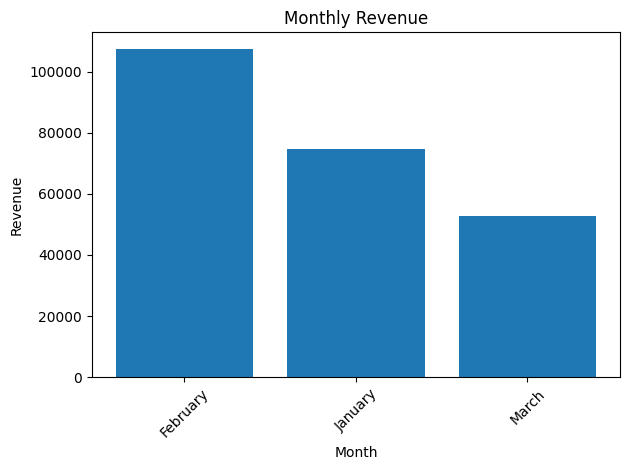


========== PIPELINE COMPLETED SUCCESSFULLY ==========


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("========== SALES DATA CLEANING PIPELINE STARTED ==========\n")

# -------------------------------------------------
# STEP 1: LOAD DATA
# -------------------------------------------------
print("Loading dataset...\n")
df = pd.read_csv("raw_sales.csv")  # In VS Code: "../data/raw_sales.csv"

print("Initial Shape:", df.shape)
print(df.head(), "\n")


# -------------------------------------------------
# STEP 2: REMOVE DUPLICATES
# -------------------------------------------------
print("Removing duplicates...")
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape, "\n")


# -------------------------------------------------
# STEP 3: HANDLE MISSING VALUES
# -------------------------------------------------
print("Handling missing values...")

# Fill Region with mode
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

# Fill Discount with 0
df["Discount"] = df["Discount"].fillna(0)

# Drop rows where Customer_Name is missing
df = df.dropna(subset=["Customer_Name"])

print("Missing values handled.\n")


# -------------------------------------------------
# STEP 4: CLEAN DATE COLUMN
# -------------------------------------------------
print("Fixing date formats...")

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce",
    dayfirst=True
)

# Remove invalid dates
df = df[df["Order_Date"].notna()]

print("Date cleaning done.\n")


# -------------------------------------------------
# STEP 5: CLEAN PRICE COLUMN
# -------------------------------------------------
print("Cleaning currency column...")

df["Price"] = (
    df["Price"]
    .replace("[₹,]", "", regex=True)
    .astype(float)
)

print("Price column cleaned.\n")


# -------------------------------------------------
# STEP 6: STANDARDIZE TEXT COLUMNS
# -------------------------------------------------
print("Standardizing text columns...")

text_cols = ["Category", "Region", "Customer_Name"]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print("Text columns standardized.\n")


# -------------------------------------------------
# STEP 7: REMOVE INVALID QUANTITY
# -------------------------------------------------
print("Removing negative quantities...")

df = df[df["Quantity"] > 0]

print("Invalid quantities removed.\n")


# -------------------------------------------------
# STEP 8: CREATE REVENUE COLUMN
# -------------------------------------------------
print("Calculating revenue...")

df["Revenue"] = df["Quantity"] * df["Price"] * (1 - df["Discount"])

# Remove old Total_Sales column if exists
if "Total_Sales" in df.columns:
    df = df.drop(columns=["Total_Sales"])

print("Revenue calculated.\n")


# -------------------------------------------------
# STEP 9: FEATURE ENGINEERING
# -------------------------------------------------
print("Creating date features...")

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Quarter"] = df["Order_Date"].dt.quarter

print("Date features created.\n")


# -------------------------------------------------
# STEP 10: CUSTOMER SEGMENTATION
# -------------------------------------------------
print("Creating customer segmentation...")

customer_sales = df.groupby("Customer_Name")["Revenue"].sum()

df["Customer_Type"] = df["Customer_Name"].map(
    lambda x: "High Value" if customer_sales[x] > 100000 else "Regular"
)

print("Customer segmentation done.\n")


# -------------------------------------------------
# STEP 11: REMOVE OUTLIERS (IQR METHOD)
# -------------------------------------------------
print("Removing outliers using IQR...")

Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df["Revenue"] >= Q1 - 1.5 * IQR) &
    (df["Revenue"] <= Q3 + 1.5 * IQR)
]

print("Outliers removed.\n")


# -------------------------------------------------
# STEP 12: GENERATE KPIs
# -------------------------------------------------
print("Generating KPIs...\n")

total_revenue = df["Revenue"].sum()
avg_order_value = df["Revenue"].mean()

category_sales = df.groupby("Category")["Revenue"].sum().reset_index()
region_sales = df.groupby("Region")["Revenue"].sum().reset_index()
monthly_sales = df.groupby("Month_Name")["Revenue"].sum().reset_index()

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)

print("\nTop Category:")
print(category_sales.sort_values(by="Revenue", ascending=False).head(1))

print("\nTop Region:")
print(region_sales.sort_values(by="Revenue", ascending=False).head(1))


# -------------------------------------------------
# STEP 13: EXPORT CLEANED DATA
# -------------------------------------------------
print("\nExporting cleaned dataset...")

df.to_csv("cleaned_sales.csv", index=False)

with pd.ExcelWriter("summary_report.xlsx") as writer:
    category_sales.to_excel(writer, sheet_name="Category Sales", index=False)
    region_sales.to_excel(writer, sheet_name="Region Sales", index=False)
    monthly_sales.to_excel(writer, sheet_name="Monthly Sales", index=False)

print("Files exported successfully.\n")


# -------------------------------------------------
# STEP 14: VISUALIZATION
# -------------------------------------------------
print("Generating monthly revenue chart...")

monthly_sales = monthly_sales.sort_values("Revenue", ascending=False)

plt.figure()
plt.bar(monthly_sales["Month_Name"], monthly_sales["Revenue"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

print("\n========== PIPELINE COMPLETED SUCCESSFULLY ==========")

In [3]:
from IPython.display import display

print("\n========== CLEANED DATA PREVIEW ==========\n")

styled_df = (
    df.head(10)
    .style
    .format({
        "Price": "₹{:,.0f}",
        "Revenue": "₹{:,.0f}",
        "Discount": "{:.0%}"
    })
    .set_properties(**{
        'background-color': '#f9f9f9',
        'border-color': 'black'
    })
    .highlight_max(subset=["Revenue"], color="lightgreen")
)

display(styled_df)


========== CLEANED DATA PREVIEW ==========



,Order_ID,Order_Date,Customer_Name,Region,Product,Category,Quantity,Price,Discount,Revenue,Year,Month,Month_Name,Quarter,Customer_Type
1,1002,2024-01-15 00:00:00,Anita Verma,South,Mobile,Electronics,1,"₹20,000",0%,"₹20,000",2024,1,January,1,Regular
2,1003,2024-01-18 00:00:00,Rohit Gupta,North,Tablet,Electronics,3,"₹15,000",5%,"₹42,750",2024,1,January,1,Regular
3,1004,2024-01-20 00:00:00,Priya Singh,East,Chair,Furniture,5,"₹3,000",20%,"₹12,000",2024,1,January,1,Regular
5,1006,2024-02-15 00:00:00,Amit Joshi,West,Sofa,Furniture,1,"₹25,000",0%,"₹25,000",2024,2,February,1,High Value
6,1007,2024-02-18 00:00:00,Neha Kapoor,South,Laptop,Electronics,1,"₹50,000",15%,"₹42,500",2024,2,February,1,Regular
7,1008,2024-02-20 00:00:00,Rohit Gupta,North,Mobile,Electronics,2,"₹20,000",0%,"₹40,000",2024,2,February,1,Regular
9,1009,2024-03-01 00:00:00,Priya Singh,East,Table,Furniture,3,"₹5,000",10%,"₹13,500",2024,3,March,1,Regular
10,1010,2024-03-05 00:00:00,Anita Verma,South,Tablet,Electronics,1,"₹15,000",5%,"₹14,250",2024,3,March,1,Regular
13,1013,2024-03-10 00:00:00,Neha Kapoor,South,Sofa,Furniture,1,"₹25,000",0%,"₹25,000",2024,3,March,1,Regular


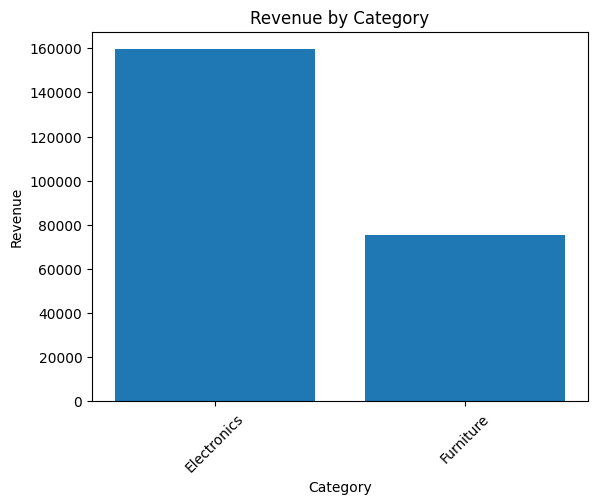

In [4]:
plt.figure()
plt.bar(category_sales["Category"], category_sales["Revenue"])
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

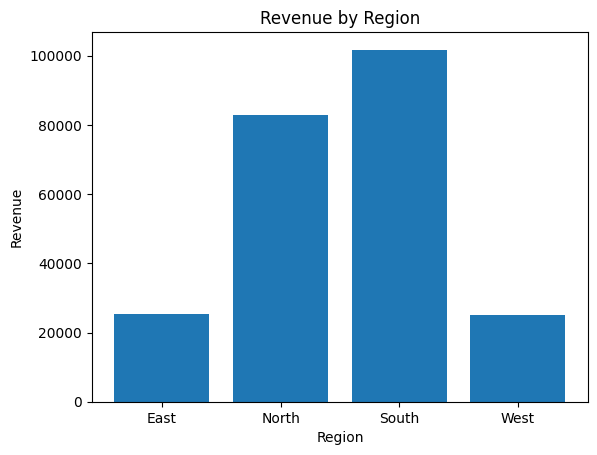

In [5]:
plt.figure()
plt.bar(region_sales["Region"], region_sales["Revenue"])
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

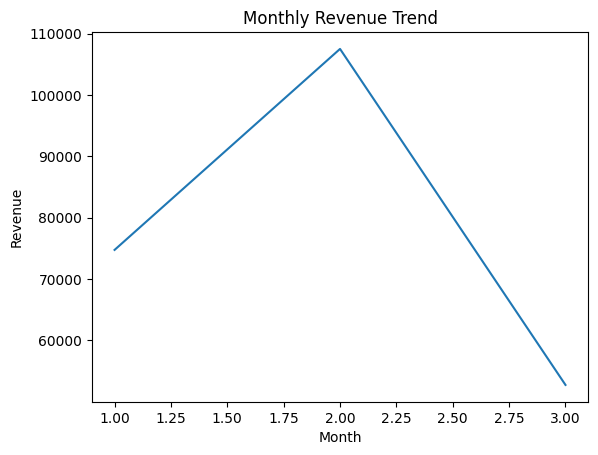

In [6]:
monthly_trend = df.groupby("Month")["Revenue"].sum().reset_index()

plt.figure()
plt.plot(monthly_trend["Month"], monthly_trend["Revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

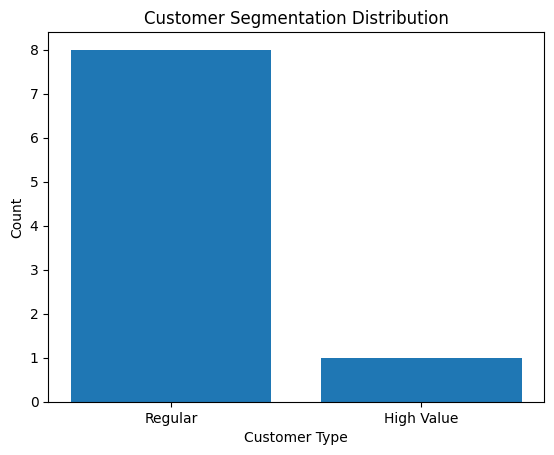

In [7]:
customer_counts = df["Customer_Type"].value_counts()

plt.figure()
plt.bar(customer_counts.index, customer_counts.values)
plt.title("Customer Segmentation Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

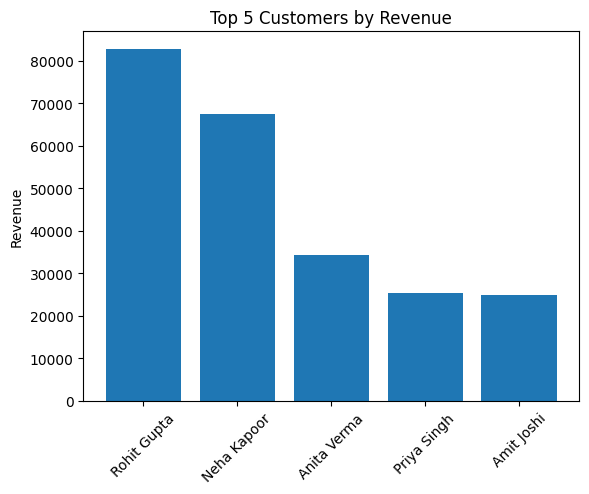

In [8]:
top_customers = (
    df.groupby("Customer_Name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure()
plt.bar(top_customers.index, top_customers.values)
plt.xticks(rotation=45)
plt.title("Top 5 Customers by Revenue")
plt.ylabel("Revenue")
plt.show()

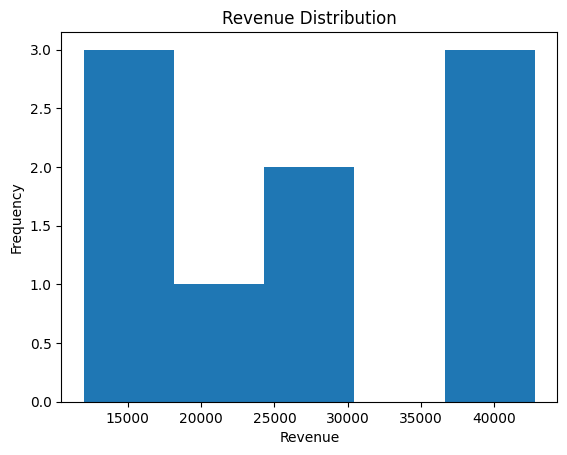

In [9]:
plt.figure()
plt.hist(df["Revenue"], bins=5)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [10]:
print("\n========== BUSINESS SUMMARY ==========\n")

print(f"Total Revenue Generated: ₹{total_revenue:,.0f}")
print(f"Average Order Value: ₹{avg_order_value:,.0f}")
print(f"Total Orders: {len(df)}")
print(f"Unique Customers: {df['Customer_Name'].nunique()}")

print("\nTop Performing Category:")
print(category_sales.sort_values(by="Revenue", ascending=False).head(1))

print("\nTop Performing Region:")
print(region_sales.sort_values(by="Revenue", ascending=False).head(1))


========== BUSINESS SUMMARY ==========

Total Revenue Generated: ₹235,000
Average Order Value: ₹26,111
Total Orders: 9
Unique Customers: 5

Top Performing Category:
      Category   Revenue
0  Electronics  159500.0

Top Performing Region:
  Region   Revenue
2  South  101750.0
